# TURBO LP 事件事实表（Notebook 1）

这一本只做一件事：把链上发生的 **Burn、后续 Mint、以及连续操作的归并结果**整理成可复核的数据表。

它严格分成三层：

1. **原始事件层**：每一条 Mint/Burn 都保留，不删掉“不好解释”的记录；
2. **事件链接层**：给每个候选 Burn 寻找同一钱包后续的 Mint，每条 Mint 最多使用一次；
3. **Campaign 层**：把尚未恢复完、又继续发生 Burn/Mint 的连续过程合并，避免重复计算同一笔资金。

本 Notebook 不判断操作者是自动还是手动，不说“永久退出”，也不讨论滑点或交易策略。滑点和资金去向将由后续两个独立 Notebook 读取这里冻结的结果。

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "notebooks" / "data" / "turbo_lp_event_ledger_v1"

manifest = json.loads((DATA_DIR / "manifest.json").read_text())
raw = pd.read_parquet(DATA_DIR / "lp_raw_events_v1.parquet")
links = pd.read_parquet(DATA_DIR / "lp_readd_links_v1.parquet")
campaigns = pd.read_parquet(DATA_DIR / "lp_campaign_ledger_v1.parquet")

pd.set_option("display.max_columns", 50)
display(pd.Series({
    "样本开始": manifest["cohort_from_time"],
    "候选 Burn 截止": manifest["cohort_end_time"],
    "后续追踪截止（finalized）": manifest["followup_data_end_time"],
    "原始事件": len(raw),
    "Burn→Mint 链接": len(links),
    "去重后 Campaign": len(campaigns),
}, name="value").to_frame())

,value
样本开始,2026-06-04T03:20:59+00:00
候选 Burn 截止,2026-09-02T03:20:59+00:00
后续追踪截止（finalized）,2026-09-10T04:51:35+00:00
原始事件,918
Burn→Mint 链接,448
去重后 Campaign,159


## 1. 为什么要冻结两个截止点？

- **候选 Burn 截止点**：决定哪些 Burn 可以进入这次研究样本；以后重跑也不会不断混入新 Burn。
- **后续追踪截止点**：只用来观察这些既定 Burn 后来有没有 Mint；这里固定为当时已经 finalized 的区块。

大白话说：先把“要考察的 Burn 名单”封卷，再多留一段时间看它们的后续。这样不会因为今天和下周运行时间不同，样本定义也跟着改变。

In [2]:
pool_rows = pd.DataFrame(manifest["scanned_pools"])[[
    "pool_address", "fee", "tick_spacing", "creation_block", "verified_at_block"
]].copy()
pool_rows["fee_pct"] = pool_rows.fee / 10_000
display(Markdown("### Factory 动态发现并核验的 TURBO/WETH V3 池"))
display(pool_rows[["pool_address", "fee_pct", "tick_spacing", "creation_block", "verified_at_block"]])

### Factory 动态发现并核验的 TURBO/WETH V3 池

,pool_address,fee_pct,tick_spacing,creation_block,verified_at_block
0,0x7baecE5d47f1BC5E1953FBE0E9931D54DAB6D810,1.0,200,17168073,25944714
1,0x8107fcA5494375Fc743A9Fc4d4844353a1AF3D94,0.3,60,17177272,25944714


这里没有预先写死“只查 0.3% 或 1%”。代码直接读取 Factory 的 `PoolCreated` 记录，再用 Factory 和池合约逐个反查验证。截止冻结区块，共找到两个 TURBO/WETH V3 池。

In [3]:
coverage = (raw.groupby(["pool_address", "fee", "event_type", "in_cohort"])
            .size().rename("event_count").reset_index())
coverage["范围"] = coverage.in_cohort.map({True: "候选样本期", False: "仅后续追踪期"})
display(coverage.drop(columns="in_cohort"))

match_quality = (raw.groupby(["event_type", "position_match_status"])
                 .size().rename("event_count").reset_index())
display(Markdown("### NFT / 钱包匹配情况"))
display(match_quality)

,pool_address,fee,event_type,event_count,范围
0,0x7baecE5d47f1BC5E1953FBE0E9931D54DAB6D810,10000,Burn,1,仅后续追踪期
1,0x7baecE5d47f1BC5E1953FBE0E9931D54DAB6D810,10000,Burn,460,候选样本期
2,0x7baecE5d47f1BC5E1953FBE0E9931D54DAB6D810,10000,Mint,1,仅后续追踪期
3,0x7baecE5d47f1BC5E1953FBE0E9931D54DAB6D810,10000,Mint,455,候选样本期
4,0x8107fcA5494375Fc743A9Fc4d4844353a1AF3D94,3000,Burn,1,候选样本期


### NFT / 钱包匹配情况

,event_type,position_match_status,event_count
0,Burn,position_manager_matched,452
1,Burn,unmatched_pool_event,10
2,Mint,position_manager_matched,454
3,Mint,unmatched_pool_event,2


## 2. 原始事件层做了什么？

它保存了两个池中每条 Mint 和 Burn 的链上位置、交易哈希、代币数量、钱包识别结果及是否位于候选样本期。

主池样本期原有 **455 条 Mint、460 条 Burn**；后续追踪期又观察到 1 条 Mint 和 1 条 Burn。0.3% 池在整个范围内只有 1 条 Burn、没有 Mint。

不是所有池事件都能与标准 Uniswap V3 Position Manager 的 NFT 一一匹配。未匹配记录仍留在原始表并标记原因，只是不拿它们启动标准 NFT campaign；这样不会把数据缺口偷偷当成 0。

In [4]:
event_summary = pd.Series({
    "候选 Burn 事件": int(raw.starts_campaign.sum()),
    "至少找到一条后续 Mint 的 Burn": int(links.origin_burn_event_id.nunique()),
    "唯一使用的后续 Mint": int(links.mint_event_id.nunique()),
    "未找到后续 Mint 的候选 Burn": int(raw.starts_campaign.sum() - links.origin_burn_event_id.nunique()),
    "重复使用的 Mint": int(links.mint_event_id.duplicated().sum()),
}, name="count").to_frame()
display(event_summary)

first_links = links.sort_values(["mint_block_number", "mint_transaction_index", "mint_log_index"]).groupby(
    "origin_burn_event_id", as_index=False
).first()
gap_windows = {
    "同一笔交易": first_links.same_transaction,
    "同一区块": first_links.same_block,
    "1小时内": first_links.time_gap_seconds <= 3600,
    "6小时内": first_links.time_gap_seconds <= 6*3600,
    "24小时内": first_links.time_gap_seconds <= 24*3600,
    "7天内": first_links.time_gap_seconds <= 7*86400,
    "30天内": first_links.time_gap_seconds <= 30*86400,
}
gap_summary = pd.DataFrame({"范围": list(gap_windows), "Burn数量": [int(v.sum()) for v in gap_windows.values()]})
display(gap_summary)

,count
候选 Burn 事件,447
至少找到一条后续 Mint 的 Burn,446
唯一使用的后续 Mint,448
未找到后续 Mint 的候选 Burn,1
重复使用的 Mint,0


,范围,Burn数量
0,同一笔交易,0
1,同一区块,0
2,1小时内,381
3,6小时内,421
4,24小时内,444
5,7天内,445
6,30天内,446


## 3. 事件链接层是什么意思？

对每个候选 Burn，代码向后找**同一个钱包**的 Mint，并严格按区块号、交易在区块中的顺序、日志顺序排列。同一交易和同一区块会单独标记，不会因为时间戳相同而分不清先后。

这一层只说“这个钱包后来做了 Mint”，不声称 Mint 使用的一定是刚刚 Burn 出来的同一笔钱。每条 Mint 最多连接一次，防止同一条 Mint 被多个 Burn 重复当作恢复证据。

/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_78304/2785029742.py:9: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_78304/2785029742.py:9: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_78304/2785029742.py:9: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_78304/2785029742.py:9: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_78304/2785029742.py:9: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5

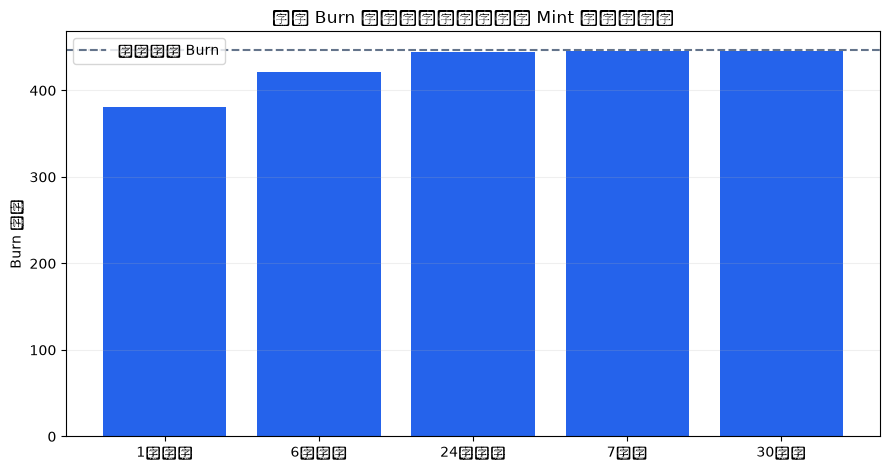

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.8))
plot = gap_summary[gap_summary["范围"].isin(["1小时内", "6小时内", "24小时内", "7天内", "30天内"])]
ax.bar(plot["范围"], plot["Burn数量"], color="#2563eb")
ax.axhline(int(raw.starts_campaign.sum()), color="#64748b", linestyle="--", label="全部候选 Burn")
ax.set_title("候选 Burn 后首次观察到同钱包 Mint 的累计数量")
ax.set_ylabel("Burn 数量")
ax.legend()
ax.grid(axis="y", alpha=.2)
plt.tight_layout()
plt.show()

,窗口,净恢复率≥90%的Campaign,净恢复率≥80%的Campaign,净恢复率中位数
0,1h,119,128,0.998667
1,6h,134,142,0.998821
2,24h,148,149,0.999181
3,7d,155,155,0.999237
4,30d,157,157,0.999381


/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_78304/3359965521.py:26: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_78304/3359965521.py:26: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_78304/3359965521.py:26: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_78304/3359965521.py:26: UserWarning: Glyph 30528 (\N{CJK UNIFIED IDEOGRAPH-7740}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1_gvn5c17bwx0djrtyj1m0000gn/T/ipykernel_78304/3359965521.py:26: UserWarning: Glyph 35266 (\N{CJK UNIFIED IDEOGRAPH-89C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/56/4nq1

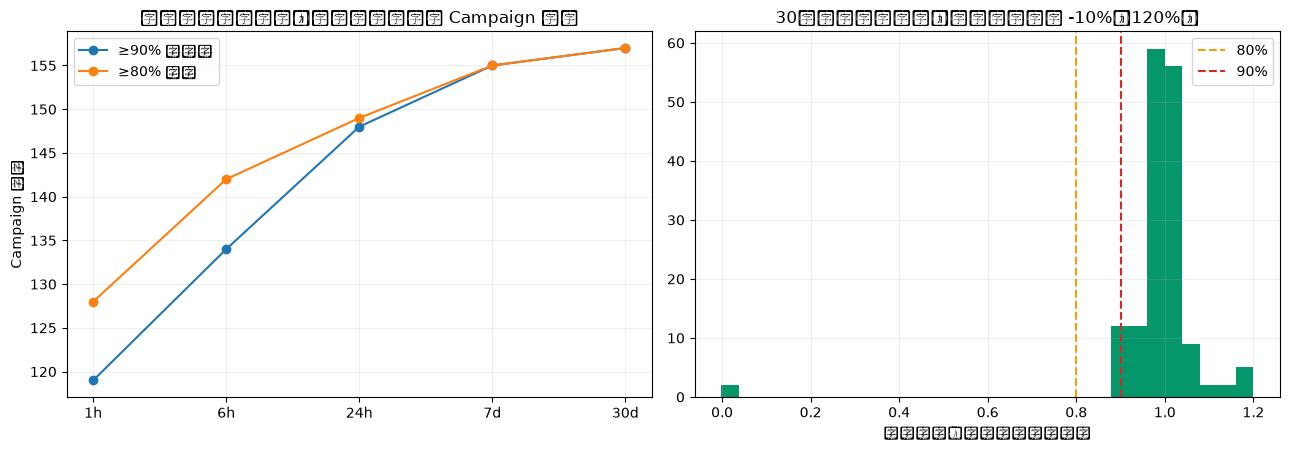

In [6]:
window_labels = ["1h", "6h", "24h", "7d", "30d"]
recovery_summary = pd.DataFrame({
    "窗口": window_labels,
    "净恢复率≥90%的Campaign": [int((campaigns[f"net_recovery_ratio_{w}"] >= .90).sum()) for w in window_labels],
    "净恢复率≥80%的Campaign": [int((campaigns[f"net_recovery_ratio_{w}"] >= .80).sum()) for w in window_labels],
    "净恢复率中位数": [campaigns[f"net_recovery_ratio_{w}"].median() for w in window_labels],
})
display(recovery_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].plot(recovery_summary["窗口"], recovery_summary["净恢复率≥90%的Campaign"], marker="o", label="≥90% 主口径")
axes[0].plot(recovery_summary["窗口"], recovery_summary["净恢复率≥80%的Campaign"], marker="o", label="≥80% 对照")
axes[0].set_title("随着观察时间增加，达到恢复比例的 Campaign 数量")
axes[0].set_ylabel("Campaign 数量")
axes[0].legend()
axes[0].grid(alpha=.2)

finite = campaigns.net_recovery_ratio_30d.replace([np.inf, -np.inf], np.nan).dropna()
axes[1].hist(finite.clip(-.1, 1.2), bins=30, color="#059669")
axes[1].axvline(.8, color="#f59e0b", linestyle="--", label="80%")
axes[1].axvline(.9, color="#dc2626", linestyle="--", label="90%")
axes[1].set_title("30天净恢复率分布（显示范围截到 -10%～120%）")
axes[1].set_xlabel("净恢复率；原始表不截断数值")
axes[1].legend()
axes[1].grid(alpha=.2)
plt.tight_layout()
plt.show()

## 4. Campaign 层怎么算？

所有金额都先按**最初 Burn 之前最近一笔池内 Swap 的 TURBO/WETH 价格**换成 WETH 等价值，避免后来币价变化把“放回多少”算歪。代码按区块、交易和日志顺序找价格；只有缺少更近的 Swap 时才退回前一区块状态。

- **毛加入比例** = 后续累计 Mint 金额 ÷ 最初 Burn 金额；只描述总共加过多少，可能超过 100%。
- **净恢复比例** =（后续累计 Mint − 期间再次 Burn）÷ 最初 Burn 金额；这是主口径，允许低于 0，也不强行封顶为 100%。

如果净恢复尚未达到 90%，期间新的 Burn/Mint 会继续留在同一 campaign；达到 90% 后，这个 campaign 才结束，下一次候选 Burn 才开始新的 campaign。因此 **447 个候选 Burn 被整理成 159 个不重叠 campaign**。这一步正是为了不把反复流动的同一批资金累计成许多次独立退出。

In [7]:
status = campaigns.groupby("net_status_30d").agg(
    campaign_count=("campaign_id", "size"),
    median_followup_days=("followup_days", "median"),
    median_net_recovery_30d=("net_recovery_ratio_30d", "median"),
).reset_index()
display(status)

review = campaigns[campaigns.net_status_30d.ne("recovered_90")][[
    "campaign_id", "wallet_address", "burn_transaction_hash", "followup_days",
    "gross_readd_ratio_30d", "net_recovery_ratio_30d", "linked_mint_count",
    "linked_later_burn_count", "is_censored_30d",
    "persistent_non_return_scanned_pair_30d", "net_status_30d",
]]
display(Markdown("### 尚未达到主恢复口径的复查对象"))
display(review)

,net_status_30d,campaign_count,median_followup_days,median_net_recovery_30d
0,censored,1,8.083472,-0.001808
1,partial_below_80,1,76.577083,0.000000
2,recovered_90,157,55.295000,0.999384


### 尚未达到主恢复口径的复查对象

,campaign_id,wallet_address,burn_transaction_hash,followup_days,gross_readd_ratio_30d,net_recovery_ratio_30d,linked_mint_count,linked_later_burn_count,is_censored_30d,persistent_non_return_scanned_pair_30d,net_status_30d
0,lp-campaign-00001,0x34756D8400f2426851dc46D6ab38F0Df004CE1E7,0x013a9096e910e3b5765e286f3a4ff376590e2c31db7c...,76.577083,0.000000,0.000000,0,0,False,True,partial_below_80
158,lp-campaign-00159,0xC216BfA5dA000965E820845c32e6FD88DB275743,0x323346c50adcb19067f2396b51e2aa11da1a4c380864...,8.083472,0.821463,-0.001808,1,1,True,False,censored


这里必须区分两种情况：

- **观察已满30天且扫描范围内没有 Mint**：只能叫“30天持续未回归候选”，不能叫永久离场；
- **观察不足30天**：标记 `censored`（还没观察够），即使当前净恢复率很低，也暂时不能放进30天未恢复结论。

本次冻结结果里，159 个 campaign 中 157 个达到 90% 主口径；1 个观察已满30天且在已扫描 TURBO/WETH 池中没有回归；另 1 个只观察了约8天，因此仍是截断样本。

In [8]:
# 机器可复核的底线检查。任何一条失败，Notebook 会直接报错。
assert links.mint_event_id.duplicated().sum() == 0, "同一 Mint 被重复分配"
assert raw.event_id.duplicated().sum() == 0, "原始事件 ID 不唯一"
assert int(raw.starts_campaign.sum()) == manifest["row_counts"]["campaign_start_burns"]
assert set(campaigns.net_status_30d) <= {"recovered_90", "recovered_80_to_90", "partial_below_80", "censored"}
assert int((raw.pool_address.str.lower() != manifest["scanned_pools"][0]["pool_address"].lower()).sum()) == 1
print("QA passed: event IDs unique; Mint links not reused; status labels and frozen counts consistent.")

QA passed: event IDs unique; Mint links not reused; status labels and frozen counts consistent.


## 5. 冻结输出在哪里？

- `notebooks/data/turbo_lp_event_ledger_v1/lp_raw_events_v1.parquet`：全部原始 Mint/Burn；
- `notebooks/data/turbo_lp_event_ledger_v1/lp_readd_links_v1.parquet`：事件级 Burn→Mint 链接；
- `notebooks/data/turbo_lp_event_ledger_v1/lp_campaign_ledger_v1.parquet`：去重后的 campaign 与多窗口恢复率；
- `notebooks/data/turbo_lp_event_ledger_v1/factory_pools.json`：Factory 动态发现并验证的池清单；
- `notebooks/data/turbo_lp_event_ledger_v1/manifest.json`：两个截止区块、口径、文件哈希和生成版本。

后续的空窗/价格冲击 Notebook 和资金去向 Notebook 只能读取这些冻结文件，不回头改写本 Notebook 的事实分类。